# 03 — Walk-forward backtest & out-of-sample results

## Protocol

At each month-end rebalance date $t$, every strategy sees **only data up to and including $t$** (a 60-month estimation window for returns, the full price history for the BL momentum signal), produces target weights under the common constraint set, and holds them over month $t\!+\!1$. No information from the future ever enters the optimisation — the no-look-ahead property is tested explicitly at the end of this notebook.

- **Out-of-sample period: July 2012 → December 2025** (~13.5 years; 2007–2012 is the burn-in for the first 60m window). It includes two of our crisis regimes (COVID 2020, inflation 2022) plus three smaller stress episodes.
- **Strategies**: Markowitz max-Sharpe, Michaud resampled (M = 200, fixed seed), Black–Litterman — against the two naive benchmarks required by the assignment (**60/40** SPY/AGG and **1/N**) and the **market index (SPY buy & hold)**.
- **Costs**: results are shown gross; a 10 bps one-way transaction-cost scenario on turnover is reported in section 4.
- Backtests are deterministic and cached to `data/processed/backtests/` (set `FORCE = True` to recompute).

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from src import config, data, metrics, plotting, strategies
from src.backtest import run_or_load

plotting.setup_style()
monthly, returns, rf = data.load_dataset()
FORCE = False

In [2]:
%%time
results = {}
for name, fn in strategies.STRATEGIES.items():
    results[name] = run_or_load(fn, name, returns, monthly, rf, force=FORCE)
    print(f"done: {name}  ({len(results[name].weights)} rebalances)")

done: Markowitz Max-Sharpe  (162 rebalances)
done: Michaud Resampled  (162 rebalances)
done: Black-Litterman  (162 rebalances)
done: 60/40  (162 rebalances)
done: 1/N  (162 rebalances)
CPU times: user 22.3 ms, sys: 5.63 ms, total: 28 ms
Wall time: 37.7 ms


In [3]:
# Strategy return series + the market index over the same OOS months
oos_returns = {name: res.returns for name, res in results.items()}
oos_index = list(oos_returns.values())[0].index
oos_returns[plotting.INDEX_NAME] = returns[config.MARKET_INDEX].reindex(oos_index)

# Sanity checks on every strategy (see also section 5)
for name, res in results.items():
    w = res.weights
    assert np.allclose(w.sum(axis=1), 1, atol=1e-4), f"{name}: weights must sum to 1"
    assert (w >= -1e-8).all().all(), f"{name}: long-only violated"
    assert not res.returns.isna().any(), f"{name}: NaNs in returns"
print("sanity checks passed: full investment, long-only, no NaNs")

sanity checks passed: full investment, long-only, no NaNs


## 1. Performance summary

All metrics computed on monthly out-of-sample returns; benchmark **and** market index included, as required, so we can judge whether the strategies added value.

In [4]:
turnovers = {name: res.annual_turnover for name, res in results.items()}
summary = metrics.summary_table(oos_returns, rf, turnovers)
summary.to_csv(config.DATA_PROCESSED / "summary_metrics.csv")
summary.style.format({
    "CAGR": "{:.2%}", "Ann. vol": "{:.2%}", "Sharpe": "{:.2f}", "Sortino": "{:.2f}",
    "Max DD": "{:.2%}", "Calmar": "{:.2f}", "Recovery (m)": "{:.0f}", "Ann. turnover": "{:.2f}",
}, na_rep="—")

,CAGR,Ann. vol,Sharpe,Sortino,Max DD,Calmar,Recovery (m),Ann. turnover
Markowitz Max-Sharpe,8.85%,7.62%,0.95,1.32,-19.30%,0.46,14,0.76
Michaud Resampled,7.35%,6.65%,0.87,1.22,-16.47%,0.45,17,0.60
Black-Litterman,6.15%,7.48%,0.63,1.03,-10.98%,0.56,13,2.82
60/40,9.67%,9.17%,0.88,1.19,-20.05%,0.48,17,0.12
1/N,5.82%,7.44%,0.59,0.79,-17.57%,0.33,22,0.16
SPY (index),14.74%,13.92%,0.95,1.33,-23.93%,0.62,15,—


## 2. Investment curve and drawdowns

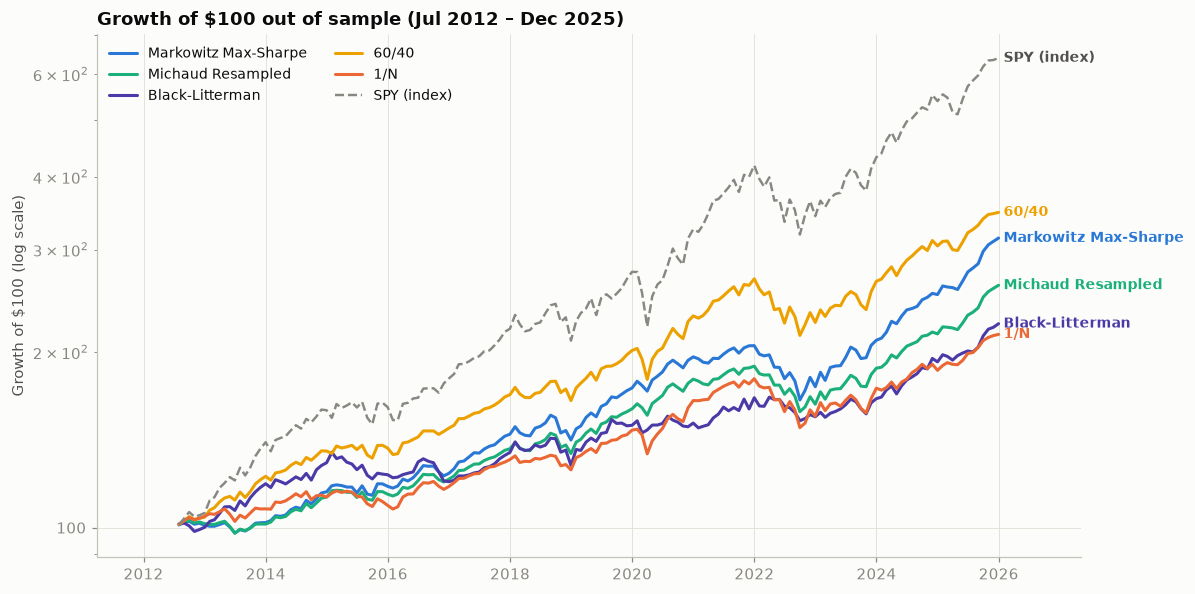

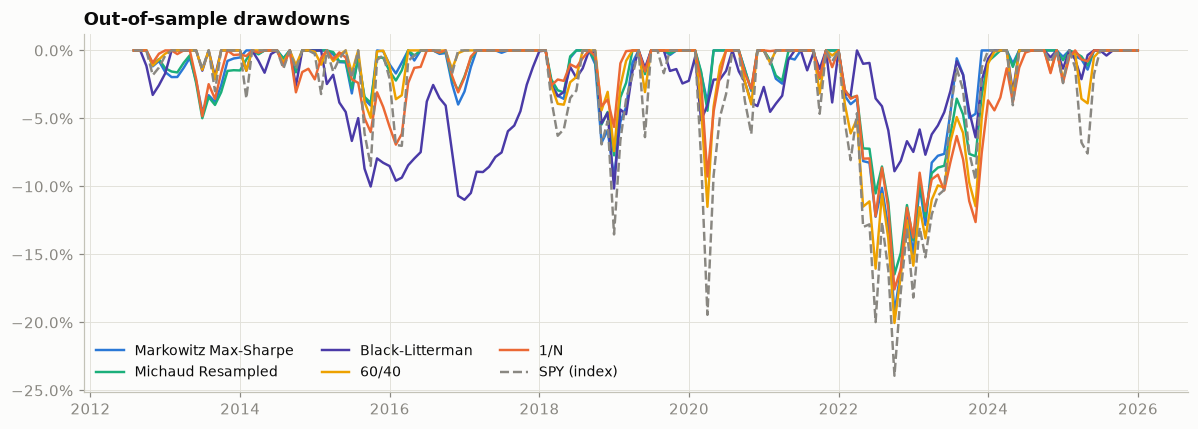

In [5]:
fig, ax = plotting.plot_investment_curves(oos_returns, "Growth of $100 out of sample (Jul 2012 – Dec 2025)")
plotting.savefig(fig, "03_investment_curve")
plt.show()

fig, ax = plotting.plot_drawdowns(oos_returns, "Out-of-sample drawdowns")
plotting.savefig(fig, "03_drawdowns")
plt.show()

## 3. What the strategies actually held

The stacked areas make the core difference visible at a glance: Markowitz jumps between corner-ish allocations at every re-estimation, Michaud's averaged weights evolve smoothly, and BL stays anchored near equilibrium with momentum tilts. Colors are shades of one hue per bucket (blue = equity, green = bonds, warm = alternatives).

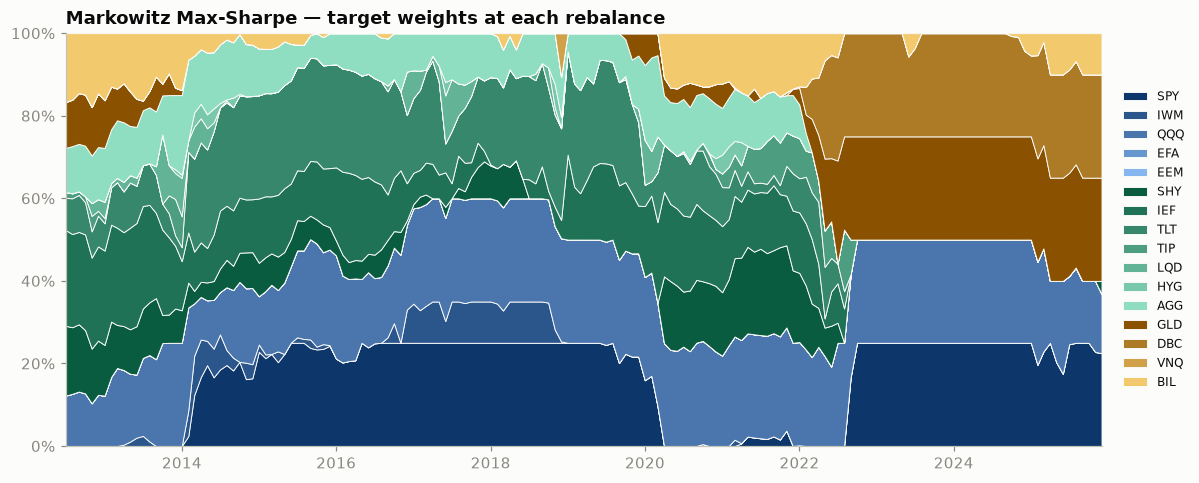

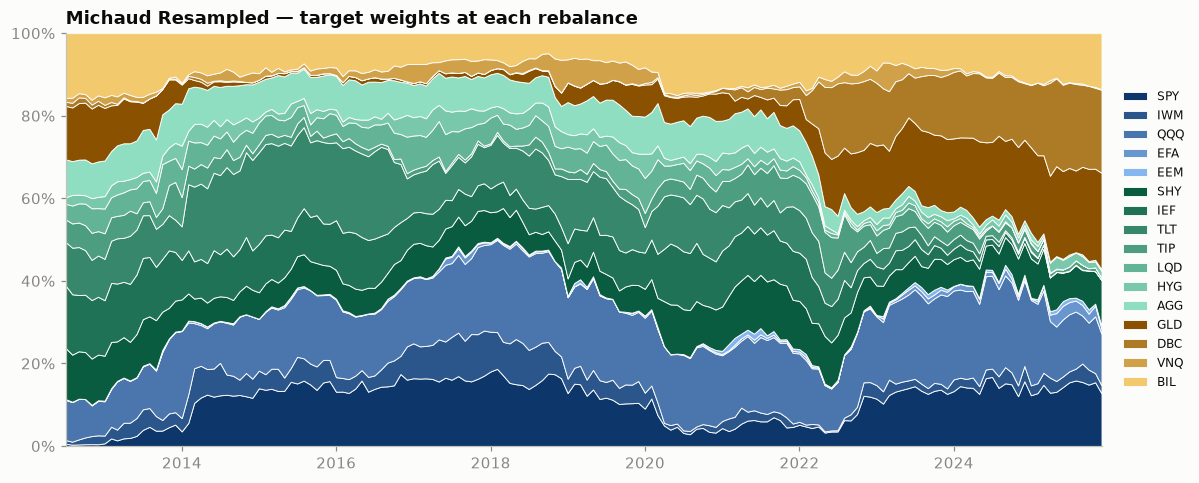

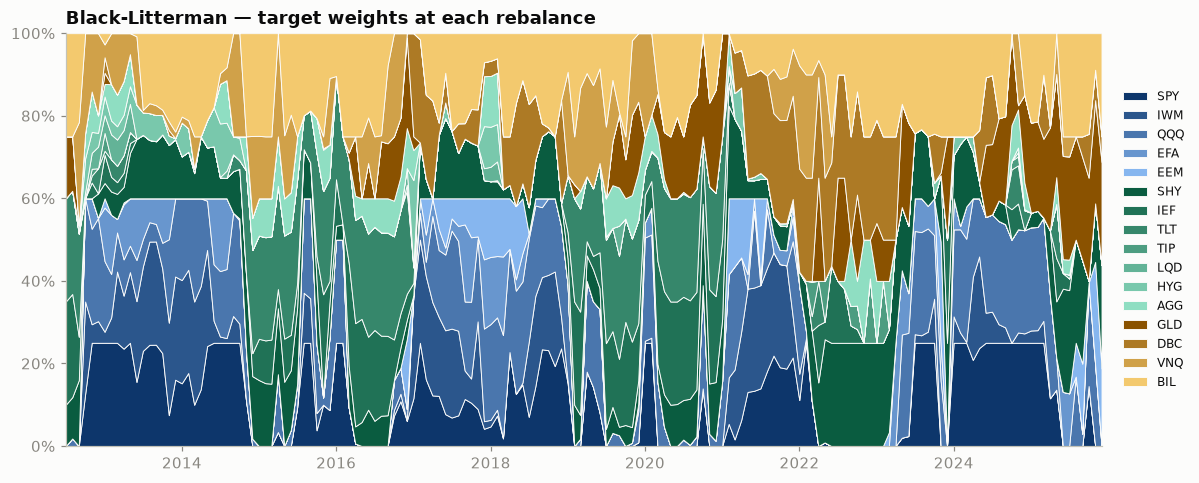

In [6]:
for name in ["Markowitz Max-Sharpe", "Michaud Resampled", "Black-Litterman"]:
    fig, ax = plotting.plot_weights(results[name].weights, f"{name} — target weights at each rebalance")
    plotting.savefig(fig, f"03_weights_{name.split()[0].lower().replace('-', '_')}")
    plt.show()

## 4. Turnover and transaction costs

Instability is not only ugly — it is expensive. Michaud's smoother weights should translate into lower turnover; here is the same comparison net of a 10 bps one-way cost per unit traded.

In [7]:
net_results = {name: run_or_load(fn, f"{name} (net 10bps)", returns, monthly, rf,
                                 force=FORCE, tc_bps=config.TRANSACTION_COST_BPS)
               for name, fn in strategies.STRATEGIES.items()}

cost_impact = pd.DataFrame({
    "Ann. turnover (one-way)": {n: r.annual_turnover for n, r in results.items()},
    "CAGR gross": {n: metrics.cagr(r.returns) for n, r in results.items()},
    "CAGR net (10bps)": {n: metrics.cagr(r.returns) for n, r in net_results.items()},
    "Sharpe gross": {n: metrics.sharpe(r.returns, rf) for n, r in results.items()},
    "Sharpe net (10bps)": {n: metrics.sharpe(r.returns, rf) for n, r in net_results.items()},
})
cost_impact["cost drag (bps/y)"] = (cost_impact["CAGR gross"] - cost_impact["CAGR net (10bps)"]) * 1e4
cost_impact.style.format({"Ann. turnover (one-way)": "{:.2f}", "CAGR gross": "{:.2%}",
                          "CAGR net (10bps)": "{:.2%}", "Sharpe gross": "{:.2f}",
                          "Sharpe net (10bps)": "{:.2f}", "cost drag (bps/y)": "{:.0f}"})

,Ann. turnover (one-way),CAGR gross,CAGR net (10bps),Sharpe gross,Sharpe net (10bps),cost drag (bps/y)
Markowitz Max-Sharpe,0.76,8.85%,8.68%,0.95,0.93,16
Michaud Resampled,0.60,7.35%,7.23%,0.87,0.85,13
Black-Litterman,2.82,6.15%,5.56%,0.63,0.55,59
60/40,0.12,9.67%,9.64%,0.88,0.88,3
1/N,0.16,5.82%,5.79%,0.59,0.58,3


## 5. Rolling Sharpe and no-look-ahead test

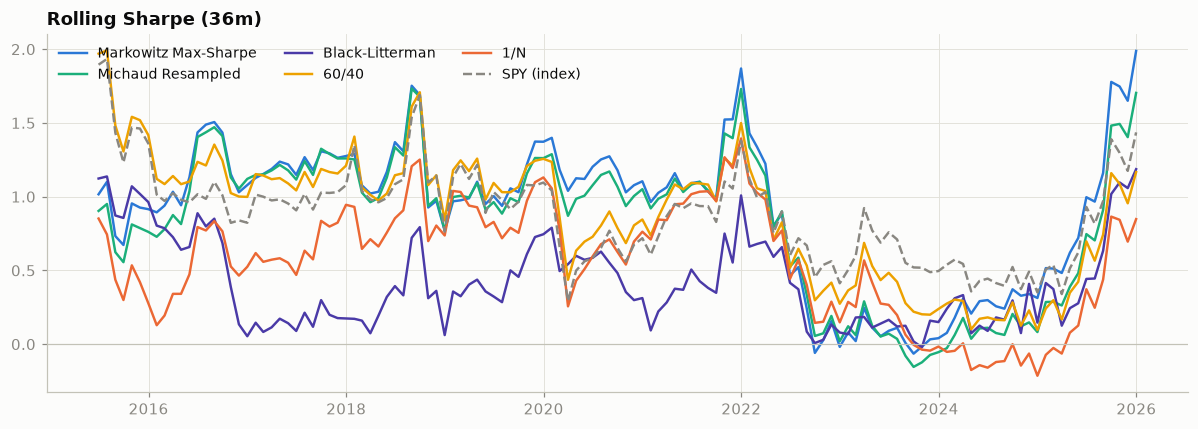

In [8]:
fig, ax = plotting.plot_rolling_sharpe(oos_returns, rf)
plotting.savefig(fig, "03_rolling_sharpe")
plt.show()

In [9]:
# No-look-ahead test: truncating the future must not change past decisions.
from src.backtest import run_backtest
cutoff = pd.Timestamp("2018-12-31")
full = results["Markowitz Max-Sharpe"].weights.loc[:cutoff]
trunc = run_backtest(strategies.markowitz_max_sharpe, "truncated",
                     returns.loc[:cutoff], monthly.loc[:cutoff], rf.loc[:cutoff]).weights
# The truncated run drops its final date (no future month to invest in), so we
# compare on the rebalance dates common to both runs.
common = full.index.intersection(trunc.index)
assert len(common) == len(trunc), "unexpected rebalance-date mismatch"
assert np.allclose(full.loc[common].values, trunc.loc[common].values, atol=1e-6), "look-ahead detected!"
print(f"no-look-ahead test passed: {len(common)} rebalances up to {cutoff:%Y-%m} identical when all later data is removed")

no-look-ahead test passed: 78 rebalances up to 2018-12 identical when all later data is removed


## 6. Sensitivity of the subjective parameters

The assignment stresses that window length and rebalancing frequency are *choices*. We re-run the two main optimised strategies with a 36-month window and with quarterly rebalancing (naive benchmarks are unaffected by the window).

In [10]:
%%time
variants = {
    "Markowitz (36m window)": (strategies.markowitz_max_sharpe, {"window": config.ESTIMATION_WINDOW_ALT}),
    "Markowitz (quarterly)": (strategies.markowitz_max_sharpe, {"every": config.REBALANCE_FREQ_ALT}),
    "Michaud (quarterly)": (strategies.michaud, {"every": config.REBALANCE_FREQ_ALT}),
    "Black-Litterman (36m window)": (strategies.black_litterman, {"window": config.ESTIMATION_WINDOW_ALT}),
    "Black-Litterman (quarterly)": (strategies.black_litterman, {"every": config.REBALANCE_FREQ_ALT}),
}
sens_returns = {
    "Markowitz Max-Sharpe": results["Markowitz Max-Sharpe"].returns,
    "Michaud Resampled": results["Michaud Resampled"].returns,
    "Black-Litterman": results["Black-Litterman"].returns,
}
for name, (fn, kw) in variants.items():
    sens_returns[name] = run_or_load(fn, name, returns, monthly, rf, force=FORCE, **kw).returns

metrics.summary_table(sens_returns, rf).style.format({
    "CAGR": "{:.2%}", "Ann. vol": "{:.2%}", "Sharpe": "{:.2f}", "Sortino": "{:.2f}",
    "Max DD": "{:.2%}", "Calmar": "{:.2f}", "Recovery (m)": "{:.0f}"}, na_rep="—")

/private/tmp/claude-503/-Users-Albert1-Desktop-mondo-2025-2026-FMA-dynamic-asset-allocation/41ae6b48-5540-482b-939d-1982bf8f92c4/scratchpad/venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(
/private/tmp/claude-503/-Users-Albert1-Desktop-mondo-2025-2026-FMA-dynamic-asset-allocation/41ae6b48-5540-482b-939d-1982bf8f92c4/scratchpad/venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(


/private/tmp/claude-503/-Users-Albert1-Desktop-mondo-2025-2026-FMA-dynamic-asset-allocation/41ae6b48-5540-482b-939d-1982bf8f92c4/scratchpad/venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(
/private/tmp/claude-503/-Users-Albert1-Desktop-mondo-2025-2026-FMA-dynamic-asset-allocation/41ae6b48-5540-482b-939d-1982bf8f92c4/scratchpad/venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(


/private/tmp/claude-503/-Users-Albert1-Desktop-mondo-2025-2026-FMA-dynamic-asset-allocation/41ae6b48-5540-482b-939d-1982bf8f92c4/scratchpad/venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(


/private/tmp/claude-503/-Users-Albert1-Desktop-mondo-2025-2026-FMA-dynamic-asset-allocation/41ae6b48-5540-482b-939d-1982bf8f92c4/scratchpad/venv/lib/python3.12/site-packages/pypfopt/base_optimizer.py:307: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  self._opt.solve(


CPU times: user 1min 11s, sys: 4.94 s, total: 1min 16s
Wall time: 1min 21s


,CAGR,Ann. vol,Sharpe,Sortino,Max DD,Calmar,Recovery (m)
Markowitz Max-Sharpe,8.85%,7.62%,0.95,1.32,-19.30%,0.46,14
Michaud Resampled,7.35%,6.65%,0.87,1.22,-16.47%,0.45,17
Black-Litterman,6.15%,7.48%,0.63,1.03,-10.98%,0.56,13
Markowitz (36m window),8.25%,7.51%,0.89,1.29,-16.32%,0.51,15
Markowitz (quarterly),8.89%,7.60%,0.96,1.40,-18.95%,0.47,10
Michaud (quarterly),7.38%,6.71%,0.87,1.24,-16.19%,0.46,15
Black-Litterman (36m window),6.08%,7.81%,0.59,1.01,-10.58%,0.57,4
Black-Litterman (quarterly),5.99%,8.22%,0.56,0.81,-13.71%,0.44,47


**Michaud with a 36m window** is omitted only for compute time; its 60m-vs-36m behaviour is qualitatively the Markowitz one, dampened by the resampling (the averaging suppresses precisely the window-specific noise the 36m estimate adds).

## Takeaways

1. Full out-of-sample comparison of the three optimised strategies vs 60/40, 1/N and the market index, with the required investment curves, drawdowns, and metric tables.
2. Weight paths confirm the theory: Markowitz is erratic, Michaud smooth, BL anchored — and the ranking by turnover (hence by cost drag) follows the same order.
3. Results are qualitatively robust to the estimation window and to quarterly rebalancing.

*Whether* the robust methods earn their advantage **in crises specifically** — the research question — is addressed in notebook 04.